In [129]:
# Imports and setup
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import DataLoader
from train_lstm import prepare_train_val, SequenceDataset, LSTMModel, train_loop, val_loop
import random

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

base_seed = 451945
set_seed(base_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)


Device: cpu


In [132]:
# Parameters and data prep
out_dir = 'notebook_output'
mat_path = 'Xtrain.mat'
os.makedirs(out_dir, exist_ok=True)
seq_len = 20  # best from sweep
hidden = 50  # best from sweep
epochs = 100
batch_size = 32
num_layers = 2
dropout = 0.2
weight_decay = 1e-5
seed_candidates = [42, 123, 451945, 999, 7777]

# Load and prepare data (uses Xtrain.mat in this folder)
X_train, X_val, y_train, y_val, scaler = prepare_train_val(mat_path, seq_len)
train_ds = SequenceDataset(X_train, y_train)
val_ds = SequenceDataset(X_val, y_val)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
print('Train samples:', len(train_ds), 'Val samples:', len(val_ds))

Train samples: 780 Val samples: 200



Training seed 42
Epoch 1/100  train_loss=0.056240  val_loss=0.030749
Epoch 5/100  train_loss=0.034430  val_loss=0.028198
Epoch 10/100  train_loss=0.011561  val_loss=0.003764
Epoch 15/100  train_loss=0.008219  val_loss=0.001619
Epoch 20/100  train_loss=0.005740  val_loss=0.001677
Epoch 25/100  train_loss=0.004845  val_loss=0.001364
Epoch 30/100  train_loss=0.004028  val_loss=0.000644
Epoch 35/100  train_loss=0.003945  val_loss=0.000309
Epoch 40/100  train_loss=0.004034  val_loss=0.000209
Epoch 45/100  train_loss=0.003420  val_loss=0.000158
Epoch 50/100  train_loss=0.003438  val_loss=0.000414
Epoch 55/100  train_loss=0.002911  val_loss=0.000211
Epoch 60/100  train_loss=0.003439  val_loss=0.000662
Epoch 65/100  train_loss=0.002749  val_loss=0.000243
Epoch 70/100  train_loss=0.002590  val_loss=0.000356
Epoch 75/100  train_loss=0.002206  val_loss=0.000074
Epoch 80/100  train_loss=0.002883  val_loss=0.000781
Epoch 85/100  train_loss=0.002477  val_loss=0.000156
Epoch 90/100  train_loss=0.002

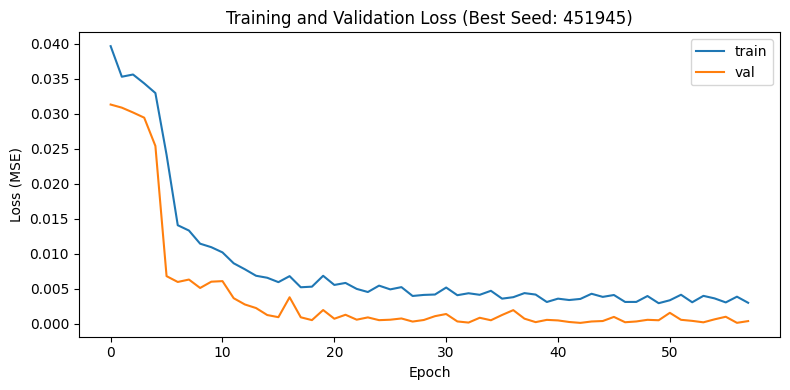

In [133]:
# Build model, train, and keep the seed with the best recursive forecast
best_recursive_mse = float('inf')
best_recursive_mae = float('inf')
best_seed = None
best_path = os.path.join(out_dir, 'best_model.pt')
best_train_losses = []
best_val_losses = []
best_val_loss = float('inf')

patience = 15

for seed in seed_candidates:
    set_seed(seed)
    model = LSTMModel(input_size=1, hidden_size=hidden, num_layers=num_layers, dropout=dropout).to(device)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    seed_path = os.path.join(out_dir, f'best_model_seed_{seed}.pt')
    train_losses = []
    val_losses = []
    counter = 0
    seed_best_val = float('inf')

    print(f'\nTraining seed {seed}')
    for epoch in range(1, epochs + 1):
        train_loss = train_loop(model, train_loader, criterion, optimizer, device)
        val_loss, _, _ = val_loop(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < seed_best_val:
            seed_best_val = val_loss
            torch.save(model.state_dict(), seed_path)
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch} with best val loss {seed_best_val:.6f}')
                break

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f'Epoch {epoch}/{epochs}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}')

    model.load_state_dict(torch.load(seed_path, map_location=device))
    model.eval()
    y_val_inv_local = scaler.inverse_transform(y_val).reshape(-1)
    window = X_val[0, :, 0].astype(np.float32).copy()
    future_scaled_local = []
    with torch.no_grad():
        for _ in range(len(y_val_inv_local)):
            x_in = torch.tensor(window, dtype=torch.float32, device=device).view(1, seq_len, 1)
            y_next = model(x_in).item()
            future_scaled_local.append(y_next)
            window = np.concatenate([window[1:], np.array([y_next], dtype=np.float32)])

    future_scaled_local = np.array(future_scaled_local, dtype=np.float32).reshape(-1, 1)
    future_pred_local = scaler.inverse_transform(future_scaled_local).reshape(-1)
    recursive_mse = mean_squared_error(y_val_inv_local, future_pred_local)
    recursive_mae = mean_absolute_error(y_val_inv_local, future_pred_local)
    print(f'Seed {seed} recursive MSE: {recursive_mse:.6f}, MAE: {recursive_mae:.6f}')

    if recursive_mse < best_recursive_mse:
        best_recursive_mse = recursive_mse
        best_recursive_mae = recursive_mae
        best_seed = seed
        best_path = seed_path
        best_train_losses = train_losses.copy()
        best_val_losses = val_losses.copy()
        best_val_loss = seed_best_val

print(f'Best seed: {best_seed}')
print(f'Best recursive MSE: {best_recursive_mse:.6f}, MAE: {best_recursive_mae:.6f}')

set_seed(best_seed)
model = LSTMModel(input_size=1, hidden_size=hidden, num_layers=num_layers, dropout=dropout).to(device)
model.load_state_dict(torch.load(best_path, map_location=device))
criterion = torch.nn.MSELoss()
train_losses = best_train_losses
val_losses = best_val_losses
best_val = best_val_loss

# Plot loss curve for the best seed
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title(f'Training and Validation Loss (Best Seed: {best_seed})')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'loss_curve.png'))
plt.show()

Validation MSE: 6.824875, MAE: 2.018028


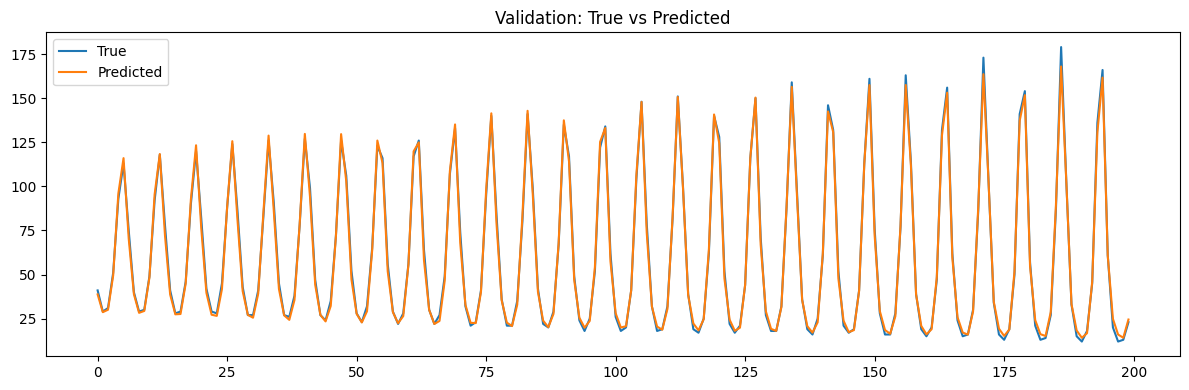

In [134]:
# Load best model and evaluate on validation set
model.load_state_dict(torch.load(best_path, map_location=device))
model.to(device)
_, y_pred_scaled, y_val_scaled = val_loop(model, val_loader, criterion, device)
# Inverse scale to original units
y_val_inv = scaler.inverse_transform(y_val_scaled).reshape(-1)
y_pred_inv = scaler.inverse_transform(y_pred_scaled).reshape(-1)
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_val_inv, y_pred_inv)
mae = mean_absolute_error(y_val_inv, y_pred_inv)
print(f'Validation MSE: {mse:.6f}, MAE: {mae:.6f}')

# Plot predictions vs true
plt.figure(figsize=(12,4))
plt.plot(y_val_inv, label='True')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.title('Validation: True vs Predicted')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'pred_vs_true_notebook.png'))
plt.show()

# Save arrays
#np.save(os.path.join(out_dir, 'y_val_true_notebook.npy'), y_val_inv)
#np.save(os.path.join(out_dir, 'y_val_pred_notebook.npy'), y_pred_inv)

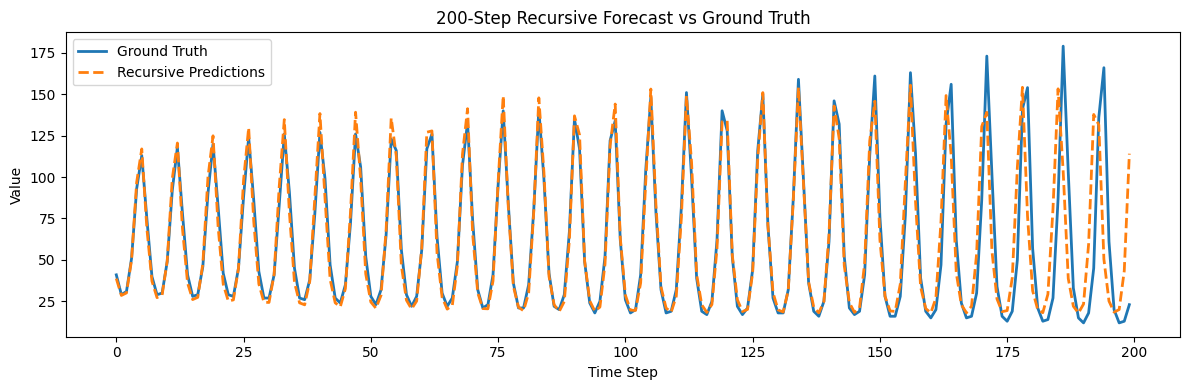

Recursive Forecast - MSE: 388.006989, MAE: 9.691211


In [135]:
# Recursive forecast for the validation horizon using the best seed checkpoint
forecast_horizon = len(y_val_inv)
window = X_val[0, :, 0].astype(np.float32).copy()
future_scaled = []

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
with torch.no_grad():
    for _ in range(forecast_horizon):
        x_in = torch.tensor(window, dtype=torch.float32, device=device).view(1, seq_len, 1)
        y_next = model(x_in).item()
        future_scaled.append(y_next)
        window = np.concatenate([window[1:], np.array([y_next], dtype=np.float32)])

future_scaled = np.array(future_scaled, dtype=np.float32).reshape(-1, 1)
future_pred = scaler.inverse_transform(future_scaled).reshape(-1)

# Compare against the aligned validation ground truth
plt.figure(figsize=(12, 4))
plt.plot(y_val_inv, label='Ground Truth', linewidth=2)
plt.plot(future_pred, label='Recursive Predictions', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.title('200-Step Recursive Forecast vs Ground Truth')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'recursive_forecast_notebook.png'))
plt.show()

# Calculate metrics on the correct horizon
mse_recursive = mean_squared_error(y_val_inv, future_pred)
mae_recursive = mean_absolute_error(y_val_inv, future_pred)
print(f'Recursive Forecast - MSE: {mse_recursive:.6f}, MAE: {mae_recursive:.6f}')